In [1]:
import MDAnalysis as mda
from numpy import *
import os
from pylab import *
import MDAnalysis.analysis.distances
import MDAnalysis.analysis.rms
from MDAnalysis.analysis import align
import glob
#import umap
import scipy.stats
import sklearn
import sklearn.decomposition
import sklearn.preprocessing
import pandas as pd
import seaborn as sns
from MDAnalysis.analysis.hydrogenbonds.hbond_analysis import HydrogenBondAnalysis as HBA

In [2]:
import os

########################################################
#############      FOR NOW EQPOINT IS 0   ##############
########################################################
EQPOINT=0

systemFolders = glob.glob("huNumbering/*t5a*/")

systemgros=[]
systemtprs=[]
systemtrjs=[]
for i in range(len(systemFolders)):
    systemgros.append(sorted(glob.glob(systemFolders[i]+"*.gro")))
    systemtprs.append(sorted(glob.glob(systemFolders[i]+"*.tpr")))
    systemtrjs.append(sorted(glob.glob(systemFolders[i]+"*.xtc")))


    
    
threeColor=["#FE6100","#332288","#882255"]
colourScheme= threeColor
system_names = ["rhT5A","T5A","T5AR332P"]
systems=[]
for i in range(len(systemgros)):
    sub=[]
    for j in range(len(systemgros[i])):
        # When using TPRs, residues are indexed from 1; so we need to add in the first residue, 1 - 1 + first resid=first resid
        #firstres = mda.Universe(systemgros[i][j]).residues.resids[0]-1
        tu = mda.Universe(systemgros[i][j],systemtrjs[i][j])
        #tu.residues.resids +=firstres
                          
        sub.append(tu)
        
    systems.append(sub)


bodys=[]
bodystrings=[]
# rhesus v1 is 326-349
# Human v1 is 324-345
#huloopstring = "resid 324:345"
#rhloopstring = "resid 326:349"
combinedLoopString="resid 324:345"
#system_loop_strings = [rhloopstring,huloopstring,huloopstring]
for i in range(len(systems)):
    sub = []
    sub2 = []
    for j in range(len(systems[i])):
        sub.append(systems[i][j].select_atoms("protein and not ("+combinedLoopString+")"))
        sub2.append("protein and not ("+combinedLoopString+")")
        
    bodys.append(sub)
    bodystrings.append(sub2)
    
    
v1s=[]
v1strings=[]
# rhesus v1 is 326-349
# Human v1 is 324-345
#huloopstring = "resid 324:345"
#rhloopstring = "resid 326:349"
combinedLoopString="resid 324:345"
#system_loop_strings = [rhloopstring,huloopstring,huloopstring]
for i in range(len(systems)):
    sub = []
    sub2 = []

    for j in range(len(systems[i])):
        sub.append(systems[i][j].select_atoms("protein and "+combinedLoopString))
        sub2.append("protein and "+combinedLoopString)

        
    v1s.append(sub)        
    v1strings.append(sub2)

    
v2s=[]
v2strings=[]
# rhesus v1 is 326-349
# Human v1 is 324-345
#huloopstring = "resid 324:345"
#rhloopstring = "resid 326:349"
combinedLoopString="resid 380:400"
#system_loop_strings = [rhloopstring,huloopstring,huloopstring]
for i in range(len(systems)):
    sub = []
    sub2 = []

    for j in range(len(systems[i])):
        sub.append(systems[i][j].select_atoms("protein and "+combinedLoopString))
        sub2.append("protein and "+combinedLoopString)

        
    v2s.append(sub)        
    v2strings.append(sub2)
                   

C:\Users\Liam\anaconda3\lib\site-packages\MDAnalysis\topology\base.py:203: DeprecationWarning: `np.int` is a deprecated alias for the builtin `int`. To silence this warning, use `int` by itself. Doing this will not modify any behavior and is safe. When replacing `np.int`, you may wish to use e.g. `np.int64` or `np.int32` to specify the precision. If you wish to review your current use, check the release note link for additional information.
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations
  residx = np.zeros_like(criteria[0], dtype=np.int)
C:\Users\Liam\anaconda3\lib\site-packages\MDAnalysis\core\selection.py:640: DeprecationWarning: `np.bool` is a deprecated alias for the builtin `bool`. To silence this warning, use `bool` by itself. Doing this will not modify any behavior and is safe. If you specifically wanted the numpy scalar type, use `np.bool_` here.
Deprecated in NumPy 1.20; for more details and guidance: h

In [3]:
def getRgs(systems,datasets,selection_strings):
    allrgs=[]
    rgs=[]
    stderrs=[]
    for i in range(len(datasets)):
        subrgs=[]
        for j in range(len(datasets[i])):
            rg=[]
            for ts in systems[i][j].trajectory: 
                rg.append((systems[i][j].trajectory.time, systems[i][j].select_atoms(selection_strings[i][j]).radius_of_gyration())[1])
            subrgs.append(rg)
        allrgs.append(subrgs)

    return allrgs

allrgs = getRgs(systems,v2s,v2strings)

systemrgs=[]
for i in range(len(allrgs)):
    trjrgs=[]
    for j in range(len(allrgs[i])):
        trjrgs.append(mean(allrgs[i][j]))
    systemrgs.append(trjrgs)


In [4]:
save("all_v2_rgs.npy",allrgs)

C:\Users\Liam\anaconda3\lib\site-packages\matplotlib\tight_bbox.py:71: RuntimeWarning: divide by zero encountered in double_scalars
  fig.patch.set_bounds(x0 / w1, y0 / h1,
C:\Users\Liam\anaconda3\lib\site-packages\matplotlib\tight_bbox.py:72: RuntimeWarning: divide by zero encountered in double_scalars
  fig.bbox.width / w1, fig.bbox.height / h1)
C:\Users\Liam\anaconda3\lib\site-packages\matplotlib\patches.py:778: RuntimeWarning: invalid value encountered in double_scalars
  self._x1 = self._x0 + self._width
C:\Users\Liam\anaconda3\lib\site-packages\matplotlib\patches.py:781: RuntimeWarning: invalid value encountered in double_scalars
  self._y1 = self._y0 + self._height


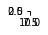

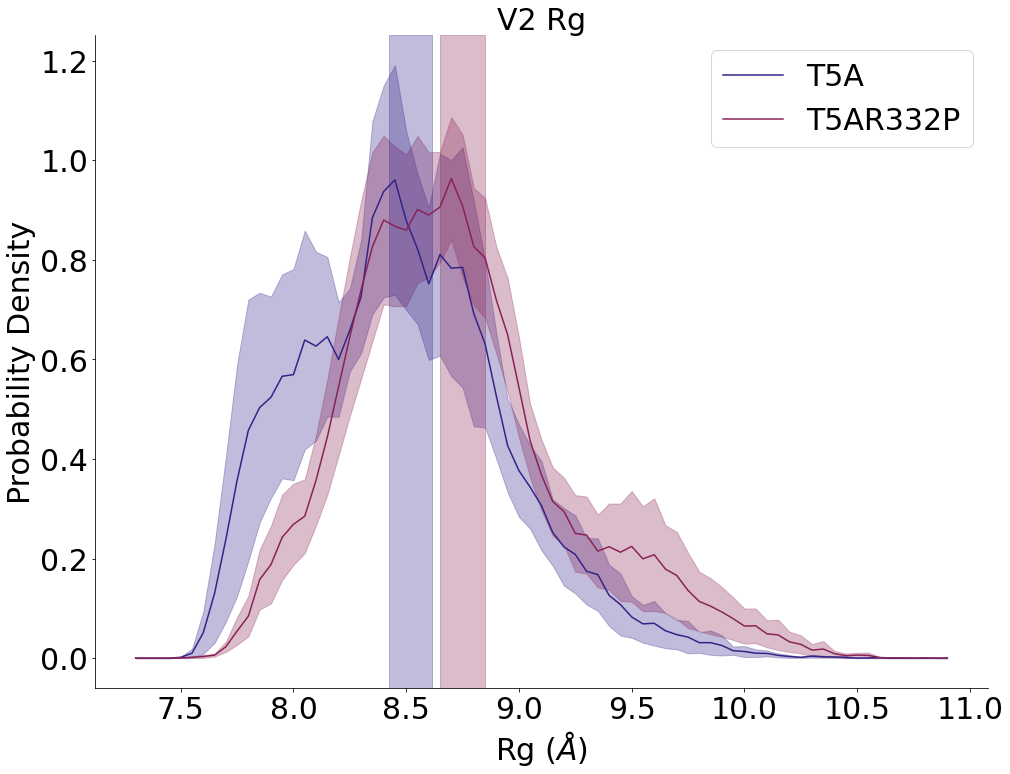

In [5]:
binrange = arange(7.3,11,.05)
all_importantrg_histsca=[]
figure(figsize = (0,0))

for i in range(len(allrgs)):
    sub=[]
    for j in range(len(allrgs[i])):
        a=hist(allrgs[i][j][EQPOINT:],bins = binrange,density = True,alpha = 0.8,color= colourScheme[0],label = system_names[0])
        sub.append(a[0])
    all_importantrg_histsca.append(sub)
    
system_avg_importantrgsca=[]
system_sem_importantrgsca=[]

for i in range(len(all_importantrg_histsca)):
    system_avg_importantrgsca.append(mean(all_importantrg_histsca[i],axis = 0))
    system_sem_importantrgsca.append(scipy.stats.sem(all_importantrg_histsca[i],axis = 0))
    
    
    
    
trjmeans = []
for i in range(len(allrgs)):
    sub = []
    for j in range(len(allrgs[i])):
        sub.append(mean(allrgs[i][j]))
    trjmeans.append(sub)
    
actualMean= [mean(trjmeans[0]),mean(trjmeans[1]),mean(trjmeans[2])]
actualSem = [scipy.stats.sem(trjmeans[0]),scipy.stats.sem(trjmeans[1]),scipy.stats.sem(trjmeans[2])]



mpl.rcParams['axes.spines.right'] = False
mpl.rcParams['axes.spines.top'] = False
figure(figsize = (16,12))
#plot(binrange[:-1],system_avg_importantrgsca[0],color = colourScheme[0],label = system_names[0])
plot(binrange[:-1],system_avg_importantrgsca[1],color = colourScheme[1],label = system_names[1])
plot(binrange[:-1],system_avg_importantrgsca[2],color = colourScheme[2],label = system_names[2])


#fill_between(binrange[:-1], system_avg_importantrgsca[0] - system_sem_importantrgsca[0],system_avg_importantrgsca[0] + system_sem_importantrgsca[0],color = colourScheme[0],alpha = 0.3)
fill_between(binrange[:-1], system_avg_importantrgsca[1] - system_sem_importantrgsca[1],system_avg_importantrgsca[1] + system_sem_importantrgsca[1],color = colourScheme[1],alpha = 0.3)
fill_between(binrange[:-1], system_avg_importantrgsca[2] - system_sem_importantrgsca[2],system_avg_importantrgsca[2] + system_sem_importantrgsca[2],color = colourScheme[2],alpha = 0.3)


xlabel("Rg ($\AA$)",fontsize = 30)
ylabel("Probability Density",fontsize = 30)
title("V2 Rg",fontsize = 30)
xticks(fontsize = 30)
yticks(fontsize = 30)

legend(fontsize = 30)

#axvspan(actualMean[0] - actualSem[0],actualMean[0]+actualSem[0], color = colourScheme[0], alpha = 0.3)
axvspan(actualMean[1] - actualSem[1],actualMean[1]+actualSem[1], color = colourScheme[1], alpha = 0.3)
axvspan(actualMean[2] - actualSem[2],actualMean[2]+actualSem[2], color = colourScheme[2], alpha = 0.3)


